# 공공 자전거 악성 미반납 예측 (STEP 1~9)
가정한 컬럼명: user_id, rent_time, return_time, payment_method, fee, distance 등
실제 clean_rentals.csv 컬럼명이 다르면 아래 설정 셀만 고치세요.

In [1]:
# 설정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

plt.rcParams["font.family"] = "Malgun Gothic"   # Mac이면 "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

COST_FN, COST_FP = 300_000, 2_000
RANDOM_STATE = 42

# 누수 후보: 반납 이후에야 확정되는 값 (실제 존재하는 컬럼만 제거됨)
LEAK_COLS = ["return_time", "duration_min", "fee", "distance", "return_station"]

# 대여 시점에 알 수 있는 범주형 피처
CAT_COLS = ["payment_method", "membership_type"]

In [ ]:
# STEP 1. 파생변수 + 정답지
OVERDUE_MIN = 100  

rentals = pd.read_csv("clean_rentals.csv", parse_dates=["rent_time", "return_time"])

rentals["duration_min"] = (rentals["return_time"] - rentals["rent_time"]).dt.total_seconds() / 60
rentals["is_overdue_24h"] = (rentals["duration_min"] > OVERDUE_MIN).astype(int)
rentals["hour"] = rentals["rent_time"].dt.hour
rentals["dayofweek"] = rentals["rent_time"].dt.dayofweek

print("전체 행 수:", len(rentals))
print(rentals["is_overdue_24h"].value_counts())
overdue_ratio = rentals["is_overdue_24h"].mean()
print(f"미반납 비율: {overdue_ratio:.4f}")
print(f"전부 정상이라 답할 때 정확도: {1 - overdue_ratio:.4f}")  # 담당자의 '98%'의 정체

전체 행 수: 13501
is_overdue_24h
0    11136
1     2365
Name: count, dtype: int64
미반납 비율: 0.1752
전부 정상이라 답할 때 정확도: 0.8248


In [3]:
# STEP 2. 결합 + 가입 기간
users = pd.read_csv("users.csv")
users["join_date"] = pd.to_datetime(users["join_date"])

n_before = len(rentals)
df = rentals.merge(users, on="user_id", how="left", validate="many_to_one")
print("결합 전/후 행 수:", n_before, len(df), n_before == len(df))
print("users 매칭 실패:", df["join_date"].isna().sum())

df["tenure_days"] = (df["rent_time"] - df["join_date"]).dt.days
print("가입일보다 대여일이 빠른 행:", (df["tenure_days"] < 0).sum())
df["tenure_days"] = df["tenure_days"].clip(lower=0)   # 음수는 0으로 보정(리포트에 명시)

결합 전/후 행 수: 13501 13501 True
users 매칭 실패: 0
가입일보다 대여일이 빠른 행: 6160


In [4]:
# STEP 3. 누수 탐지
print(df.dtypes)
leak_found = [c for c in LEAK_COLS if c in df.columns]
print("제거할 누수 컬럼:", leak_found)
# 리포트에 쓸 것:
# - return_time / duration_min : 반납 순간에 확정. 타깃이 이 값에서 직접 계산됨
# - fee : 이용 시간에 비례해 반납 시 정산 -> 24시간 초과 여부를 그대로 담고 있음
# - distance : 주행이 끝나야 확정
# 그대로 학습하면 검증에선 거의 완벽하지만, 실제 대여 시점엔 이 값이 없어 운영에선 못 씀

rental_id                      str
bike_id                        str
user_id                        str
rent_time           datetime64[us]
return_time         datetime64[us]
distance_km                float64
fee                        float64
payment_method                 str
station_id                     str
bike_type                      str
gear_count                   int64
manufacture_year           float64
daily_fee                    int64
station_name                   str
district                       str
duration_min               float64
is_overdue_24h               int64
hour                         int32
dayofweek                    int32
join_date           datetime64[us]
membership_type                str
tenure_days                  int64
dtype: object
제거할 누수 컬럼: ['return_time', 'duration_min', 'fee']


In [5]:
# STEP 4. 시점 기준 분할 + 인코딩
cutoff = df["rent_time"].quantile(0.8)
train_df = df[df["rent_time"] <= cutoff].copy()
test_df = df[df["rent_time"] > cutoff].copy()
print("기준선:", cutoff, "| train/test:", len(train_df), len(test_df))

NUM_COLS = ["hour", "dayofweek", "tenure_days"]
cat_cols = [c for c in CAT_COLS if c in df.columns]
safe_cols = NUM_COLS + cat_cols

def make_X(frame, cols, train_columns=None):
    X = pd.get_dummies(frame[cols], columns=[c for c in cat_cols if c in cols], drop_first=False)
    if train_columns is not None:
        X = X.reindex(columns=train_columns, fill_value=0)   # 테스트 열을 학습에 맞춤
    return X

y_train, y_test = train_df["is_overdue_24h"], test_df["is_overdue_24h"]
X_train = make_X(train_df, safe_cols)
X_test = make_X(test_df, safe_cols, X_train.columns)

기준선: 2022-10-20 16:21:00 | train/test: 10801 2700


In [6]:
# 평가 함수
def evaluate(model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    return {
        "정확도": accuracy_score(yte, pred),
        "정밀도": precision_score(yte, pred, zero_division=0),
        "재현율": recall_score(yte, pred, zero_division=0),
        "F1": f1_score(yte, pred, zero_division=0),
        "AUC": roc_auc_score(yte, proba),
    }

In [7]:
# STEP 5. 누수의 위력
leak_cols_in = [c for c in ["duration_min", "fee"] if c in df.columns]
X_train_leak = pd.concat([X_train, train_df[leak_cols_in]], axis=1)
X_test_leak = pd.concat([X_test, test_df[leak_cols_in]], axis=1)

rf_kwargs = dict(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
res5 = pd.DataFrame({
    "누수 제거": evaluate(RandomForestClassifier(**rf_kwargs), X_train, y_train, X_test, y_test),
    "누수 포함": evaluate(RandomForestClassifier(**rf_kwargs), X_train_leak, y_train, X_test_leak, y_test),
}).T
print(res5.round(4))

          정확도     정밀도     재현율      F1     AUC
누수 제거  0.7748  0.1629  0.0594  0.0871  0.4973
누수 포함  1.0000  1.0000  1.0000  1.0000  1.0000


In [8]:
print("전체 비율:", rentals["is_overdue_24h"].value_counts().to_dict())
print("train:", y_train.value_counts().to_dict())
print("test :", y_test.value_counts().to_dict())
print("duration_min 최대값:", df["duration_min"].max())
print(df.groupby(df["rent_time"].dt.to_period("M"))["is_overdue_24h"].agg(["sum", "count"]))

전체 비율: {0: 11136, 1: 2365}
train: {0: 8924, 1: 1877}
test : {0: 2212, 1: 488}
duration_min 최대값: 120.0
           sum  count
rent_time            
2022-01    220   1112
2022-02    179    995
2022-03    189   1095
2022-04    177   1080
2022-05    206   1130
2022-06    187   1127
2022-07    206   1202
2022-08    205   1201
2022-09    178   1125
2022-10    199   1117
2022-11    212   1133
2022-12    207   1184


In [9]:
# STEP 6. 모델 비교
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "LogReg(balanced)": make_pipeline(StandardScaler(),
                                      LogisticRegression(max_iter=1000, class_weight="balanced")),
    "RF": RandomForestClassifier(**rf_kwargs),
    "RF(balanced)": RandomForestClassifier(class_weight="balanced", **rf_kwargs),
}
res6 = pd.DataFrame({name: evaluate(m, X_train, y_train, X_test, y_test)
                     for name, m in models.items()}).T
print(res6.round(4))
# 확인 문항 요약
# 1) 양성이 약 2%라 RF도 대부분 '정상'으로 찍어 Dummy와 정확도가 거의 같음
# 2) Dummy / 불균형 모델: 정확도는 높지만 재현율 0 -> 도난을 한 건도 못 잡는 상황
# 3) balanced는 소수 클래스 오류에 가중치를 줘서 정확도는 떨어져도 재현율이 올라감

                     정확도     정밀도     재현율      F1     AUC
Dummy             0.8193  0.0000  0.0000  0.0000  0.5000
LogReg            0.8193  0.0000  0.0000  0.0000  0.4876
LogReg(balanced)  0.4667  0.1805  0.5512  0.2720  0.4878
RF                0.7748  0.1629  0.0594  0.0871  0.4973
RF(balanced)      0.6607  0.1916  0.2725  0.2250  0.5005


In [10]:
# STEP 7. 혼동행렬
rf_bal = models["RF(balanced)"]
proba_test = rf_bal.predict_proba(X_test)[:, 1]
pred_test = rf_bal.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
print(f"TP={tp}  FN={fn}  FP={fp}  TN={tn}")
# TP: 미반납을 미리 잡음 / FN: 미반납을 놓침(자전거 분실) /
# FP: 정상 이용자를 의심해 독촉 / TN: 정상을 정상으로 판단
# 이 문제는 FN(30만원)이 FP(2천원)보다 150배 비싸므로 FN이 치명적

TP=133  FN=355  FP=561  TN=1651


In [11]:
# STEP 8. 비용 기반 임계값
rows = []
for th in np.arange(0.05, 0.951, 0.05):
    pred = (proba_test >= th).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    rows.append({
        "threshold": round(th, 2), "TP": tp_, "FN": fn_, "FP": fp_,
        "recall": tp_ / (tp_ + fn_) if (tp_ + fn_) else 0,
        "precision": tp_ / (tp_ + fp_) if (tp_ + fp_) else 0,
        "total_cost": fn_ * COST_FN + fp_ * COST_FP,
    })
cost_df = pd.DataFrame(rows)
print(cost_df.round(4).to_string(index=False))

best = cost_df.loc[cost_df["total_cost"].idxmin()]
baseline_cost = int(y_test.sum()) * COST_FN   # 아무 예측도 안 할 때 = 전부 FN
print(f"\n최적 임계값: {best['threshold']}  총비용: {best['total_cost']:,.0f}원")
print(f"예측 안 할 때 비용: {baseline_cost:,}원")
print(f"절감액: {baseline_cost - best['total_cost']:,.0f}원 "
      f"({(1 - best['total_cost'] / baseline_cost):.1%})")

 threshold  TP  FN   FP  recall  precision  total_cost
      0.05 439  49 1997  0.8996     0.1802    18694000
      0.10 404  84 1815  0.8279     0.1821    28830000
      0.15 357 131 1602  0.7316     0.1822    42504000
      0.20 308 180 1425  0.6311     0.1777    56850000
      0.25 280 208 1268  0.5738     0.1809    64936000
      0.30 241 247 1117  0.4939     0.1775    76334000
      0.35 213 275  956  0.4365     0.1822    84412000
      0.40 183 305  816  0.3750     0.1832    93132000
      0.45 157 331  687  0.3217     0.1860   100674000
      0.50 134 354  565  0.2746     0.1917   107330000
      0.55 101 387  460  0.2070     0.1800   117020000
      0.60  78 410  355  0.1598     0.1801   123710000
      0.65  62 426  292  0.1270     0.1751   128384000
      0.70  51 437  236  0.1045     0.1777   131572000
      0.75  30 458  153  0.0615     0.1639   137706000
      0.80  24 464  117  0.0492     0.1702   139434000
      0.85  13 475   68  0.0266     0.1605   142636000
      0.90

tenure_days            0.537520
hour                   0.291331
dayofweek              0.147939
payment_method_CARD    0.005394
payment_method_APP     0.005330
dtype: float64


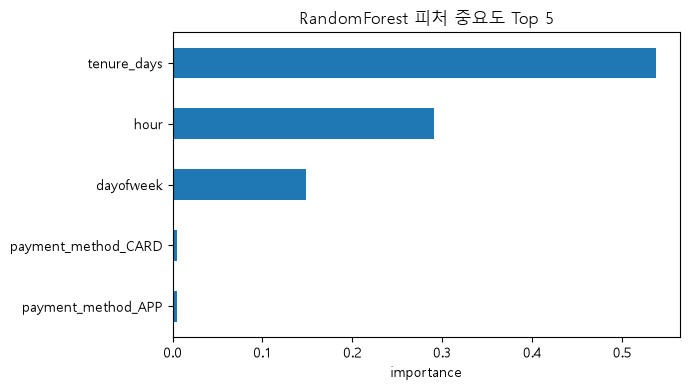

In [12]:
# STEP 9. 피처 중요도
imp = pd.Series(rf_bal.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top5 = imp.head(5)
print(top5)

plt.figure(figsize=(7, 4))
top5.sort_values().plot(kind="barh")
plt.title("RandomForest 피처 중요도 Top 5")
plt.xlabel("importance")
plt.tight_layout()
plt.show()
# 운영팀 보고 3줄은 위 결과를 보고 직접 정리하세요 (어떤 시간대/요일/가입기간이 상위인지)